In [5]:
pip install seaborn scikit-learn imbalanced-learn matplotlib joblib jupyter

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp314-cp314-win_amd64.whl.metadata (131 kB)
  Using cached kiw

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

print("Libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


In [7]:
# Load the Titanic dataset
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully.")
print("Shape:", df.shape)

Titanic dataset loaded successfully.
Shape: (891, 15)


In [8]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [9]:
# Display statistical summary
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
# Display number of rows and columns
print("Dataset shape:", df.shape)

Dataset shape: (891, 15)


In [11]:
# Calculate missing values and missing percentages
missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

# Show only columns having missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

print(missing_summary)

             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


In [12]:
# Save the original Titanic dataset inside the analytics folder
df.to_csv("titanic.csv", index=False)

print("Original Titanic dataset saved as titanic.csv")

Original Titanic dataset saved as titanic.csv


In [13]:
# Display all column names
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [14]:
# Display data type of every column
print("Data types:")
print(df.dtypes)

Data types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [19]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 107


In [16]:
# Display first 5 rows
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
# Calculate missing values and percentages
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

print("Missing-value summary:")
print(missing_summary)

Missing-value summary:
             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467


In [21]:
# Impute missing Age values with the median
age_median = df["age"].median()

df["age"] = df["age"].fillna(age_median)

print("Age median used for imputation:", age_median)
print("Missing Age values after imputation:", df["age"].isnull().sum())

Age median used for imputation: 28.0
Missing Age values after imputation: 0


In [22]:
# Drop rows with missing Embarked values
before_rows = len(df)

df = df.dropna(subset=["embarked"])

after_rows = len(df)

print("Rows before dropping missing Embarked:", before_rows)
print("Rows after dropping missing Embarked:", after_rows)
print("Rows removed:", before_rows - after_rows)

Rows before dropping missing Embarked: 891
Rows after dropping missing Embarked: 889
Rows removed: 2


In [23]:
# Drop Deck because it has a very high percentage of missing values
deck_missing_percentage = (missing_count["deck"] / len(df)) * 100

df = df.drop(columns=["deck"])

print("Deck missing percentage before handling:", round(deck_missing_percentage, 2), "%")
print("Decision: Dropped the deck column because of very high missingness.")

Deck missing percentage before handling: 77.39 %
Decision: Dropped the deck column because of very high missingness.


In [24]:
# Verify remaining missing values
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

print("Remaining missing values:")
print(remaining_missing)

if len(remaining_missing) == 0:
    print("No missing values remain in the cleaned dataset.")

Remaining missing values:
Series([], dtype: int64)
No missing values remain in the cleaned dataset.


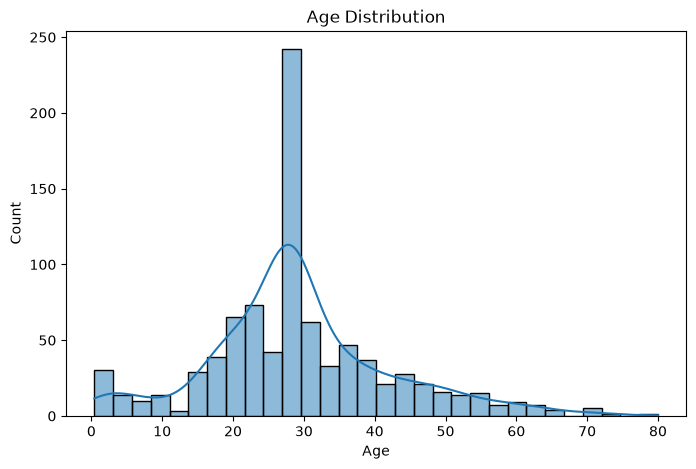

In [25]:
# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

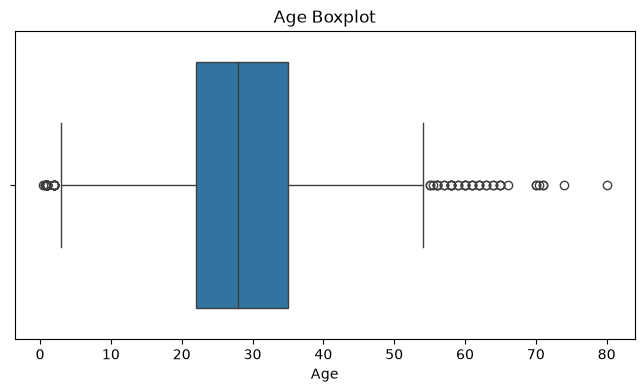

In [26]:
# Age boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["age"])
plt.title("Age Boxplot")
plt.xlabel("Age")
plt.show()

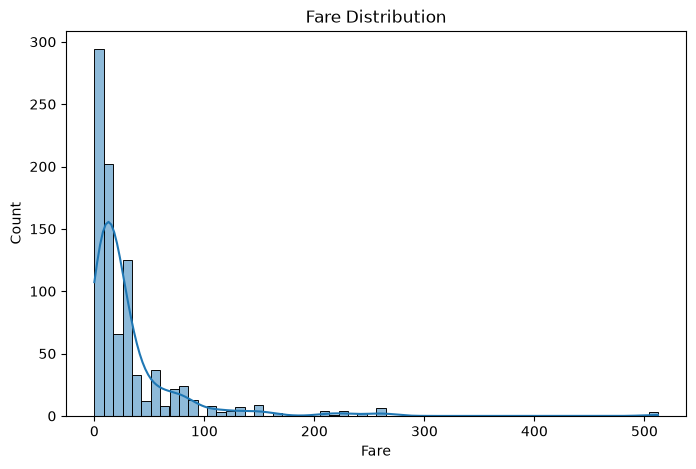

In [27]:
# Fare distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

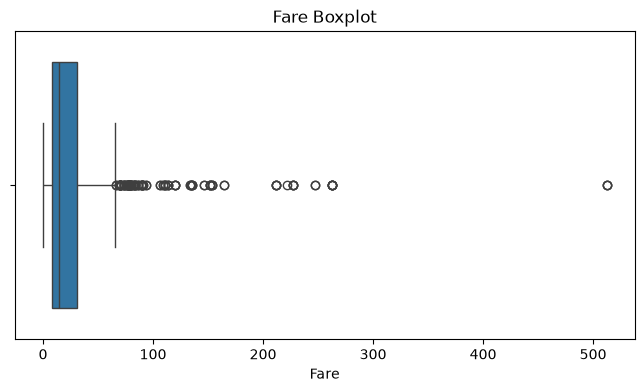

In [28]:
# Fare boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df["fare"])
plt.title("Fare Boxplot")
plt.xlabel("Fare")
plt.show()

In [29]:
# Calculate IQR outliers for Age and Fare

def calculate_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)


age_q1, age_q3, age_iqr, age_lower, age_upper, age_outliers = calculate_iqr_outliers(df["age"])
fare_q1, fare_q3, fare_iqr, fare_lower, fare_upper, fare_outliers = calculate_iqr_outliers(df["fare"])

print("Age IQR:", age_iqr)
print("Age lower bound:", age_lower)
print("Age upper bound:", age_upper)
print("Age outlier count:", age_outliers)

print("\nFare IQR:", fare_iqr)
print("Fare lower bound:", fare_lower)
print("Fare upper bound:", fare_upper)
print("Fare outlier count:", fare_outliers)

Age IQR: 13.0
Age lower bound: 2.5
Age upper bound: 54.5
Age outlier count: 65

Fare IQR: 23.1042
Fare lower bound: -26.7605
Fare upper bound: 65.6563
Fare outlier count: 114


In [30]:
# Calculate Fare mean, median and mode

fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("Fare Mean:", fare_mean)
print("Fare Median:", fare_median)
print("Fare Mode:", fare_mode)

Fare Mean: 32.09668087739032
Fare Median: 14.4542
Fare Mode: 8.05


In [32]:
# Classify Fare distribution using mean, median and mode

if fare_mean > fare_median > fare_mode:
    fare_distribution = "Right-skewed"
elif fare_mean < fare_median < fare_mode:
    fare_distribution = "Left-skewed"
else:
    fare_distribution = "Approximately symmetric or mixed"

print("Fare distribution:", fare_distribution)

Fare distribution: Right-skewed


In [35]:
# Calculate Fare skewness

fare_skewness = df["fare"].skew()

print("Fare skewness:", fare_skewness)

Fare skewness: 4.801440211044194


In [36]:
# Interpretation of Fare distribution

if fare_skewness > 0:
    print("Interpretation: Fare is positively skewed (right-skewed).")
elif fare_skewness < 0:
    print("Interpretation: Fare is negatively skewed (left-skewed).")
else:
    print("Interpretation: Fare is approximately symmetric.")

Interpretation: Fare is positively skewed (right-skewed).


In [37]:
# Task 3 summary

print("========== Task 3 Summary ==========")
print("Fare Mean:", round(fare_mean, 2))
print("Fare Median:", round(fare_median, 2))
print("Fare Mode:", round(fare_mode, 2))
print("Fare Skewness:", round(fare_skewness, 3))
print("Fare Distribution:", fare_distribution)
print("Age IQR Outliers:", age_outliers)
print("Fare IQR Outliers:", fare_outliers)

========== Task 3 Summary ==========
Fare Mean: 32.1
Fare Median: 14.45
Fare Mode: 8.05
Fare Skewness: 4.801
Fare Distribution: Right-skewed
Age IQR Outliers: 65
Fare IQR Outliers: 114


In [38]:
# Survival rate by Sex using boolean masking

male_rate = df.loc[df["sex"] == "male", "survived"].mean()
female_rate = df.loc[df["sex"] == "female", "survived"].mean()

print("Male survival rate:", round(male_rate * 100, 2), "%")
print("Female survival rate:", round(female_rate * 100, 2), "%")

Male survival rate: 18.89 %
Female survival rate: 74.04 %


In [39]:
# Survival rate by Passenger Class using boolean masking

first_class_rate = df.loc[df["pclass"] == 1, "survived"].mean()
second_class_rate = df.loc[df["pclass"] == 2, "survived"].mean()
third_class_rate = df.loc[df["pclass"] == 3, "survived"].mean()

print("1st class survival rate:", round(first_class_rate * 100, 2), "%")
print("2nd class survival rate:", round(second_class_rate * 100, 2), "%")
print("3rd class survival rate:", round(third_class_rate * 100, 2), "%")

1st class survival rate: 62.62 %
2nd class survival rate: 47.28 %
3rd class survival rate: 24.24 %


In [40]:
# Survival rate by Sex AND Passenger Class

groups = [
    ("Male, 1st Class", (df["sex"] == "male") & (df["pclass"] == 1)),
    ("Male, 2nd Class", (df["sex"] == "male") & (df["pclass"] == 2)),
    ("Male, 3rd Class", (df["sex"] == "male") & (df["pclass"] == 3)),
    ("Female, 1st Class", (df["sex"] == "female") & (df["pclass"] == 1)),
    ("Female, 2nd Class", (df["sex"] == "female") & (df["pclass"] == 2)),
    ("Female, 3rd Class", (df["sex"] == "female") & (df["pclass"] == 3))
]

for name, condition in groups:
    rate = df.loc[condition, "survived"].mean()
    print(name, ":", round(rate * 100, 2), "%")

Male, 1st Class : 36.89 %
Male, 2nd Class : 15.74 %
Male, 3rd Class : 13.54 %
Female, 1st Class : 96.74 %
Female, 2nd Class : 92.11 %
Female, 3rd Class : 50.0 %


In [41]:
# Correlation matrix using exactly the required six columns

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


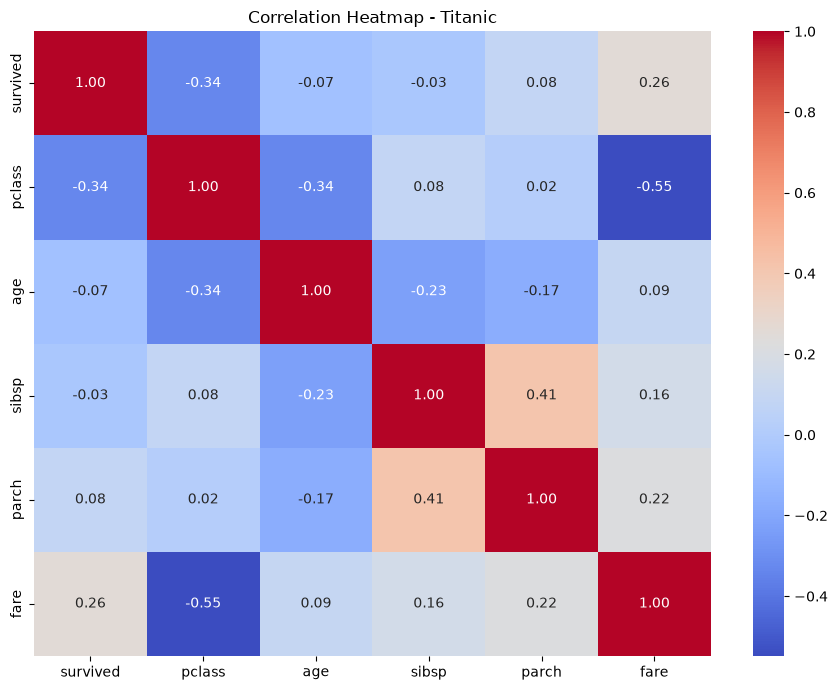

In [42]:
# Correlation heatmap

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Titanic")
plt.tight_layout()
plt.show()

In [43]:
# Find the two strongest correlations by absolute off-diagonal value

corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        value = corr_matrix.iloc[i, j]

        corr_pairs.append((col1, col2, value, abs(value)))

corr_pairs_sorted = sorted(corr_pairs, key=lambda x: x[3], reverse=True)

print("Two strongest correlations:")
for pair in corr_pairs_sorted[:2]:
    print(
        f"{pair[0]} vs {pair[1]}: "
        f"correlation = {pair[2]:.3f}"
    )

Two strongest correlations:
pclass vs fare: correlation = -0.548
sibsp vs parch: correlation = 0.415


In [44]:
# Store the two strongest correlation pairs

strongest_1 = corr_pairs_sorted[0]
strongest_2 = corr_pairs_sorted[1]

print("Strongest correlation:")
print(
    f"{strongest_1[0]} vs {strongest_1[1]} = "
    f"{strongest_1[2]:.3f}"
)

print("\nSecond strongest correlation:")
print(
    f"{strongest_2[0]} vs {strongest_2[1]} = "
    f"{strongest_2[2]:.3f}"
)

Strongest correlation:
pclass vs fare = -0.548

Second strongest correlation:
sibsp vs parch = 0.415


In [45]:
# Interpret the two strongest correlations

def interpret_correlation(pair):
    col1, col2, value, _ = pair

    if value > 0:
        direction = "positive"
    else:
        direction = "negative"

    strength = abs(value)

    if strength >= 0.7:
        level = "strong"
    elif strength >= 0.4:
        level = "moderate"
    else:
        level = "weak"

    print(
        f"{col1} and {col2} have a {level} {direction} "
        f"correlation ({value:.3f})."
    )

print("Interpretation:")
interpret_correlation(strongest_1)
interpret_correlation(strongest_2)

Interpretation:
pclass and fare have a moderate negative correlation (-0.548).
sibsp and parch have a moderate positive correlation (0.415).


In [46]:
# Save correlation matrix and strongest correlations

with open("correlation_results.txt", "w") as file:
    file.write("Titanic Correlation Analysis\n")
    file.write("============================\n\n")
    
    file.write("Correlation Matrix:\n")
    file.write(corr_matrix.to_string())
    
    file.write("\n\nTwo Strongest Correlations:\n")
    
    for rank, pair in enumerate(corr_pairs_sorted[:2], start=1):
        file.write(
            f"{rank}. {pair[0]} vs {pair[1]} = {pair[2]:.3f}\n"
        )

print("Correlation results saved to correlation_results.txt")

Correlation results saved to correlation_results.txt


In [47]:
# Verify Task 4 correlation requirements

print("Required correlation columns:")
print(correlation_columns)

print("\nNumber of correlation columns:", len(correlation_columns))

print("\nExcluded columns:")
print("adult_male")
print("alone")

print("\nTask 4 correlation analysis completed.")

Required correlation columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Number of correlation columns: 6

Excluded columns:
adult_male
alone

Task 4 correlation analysis completed.


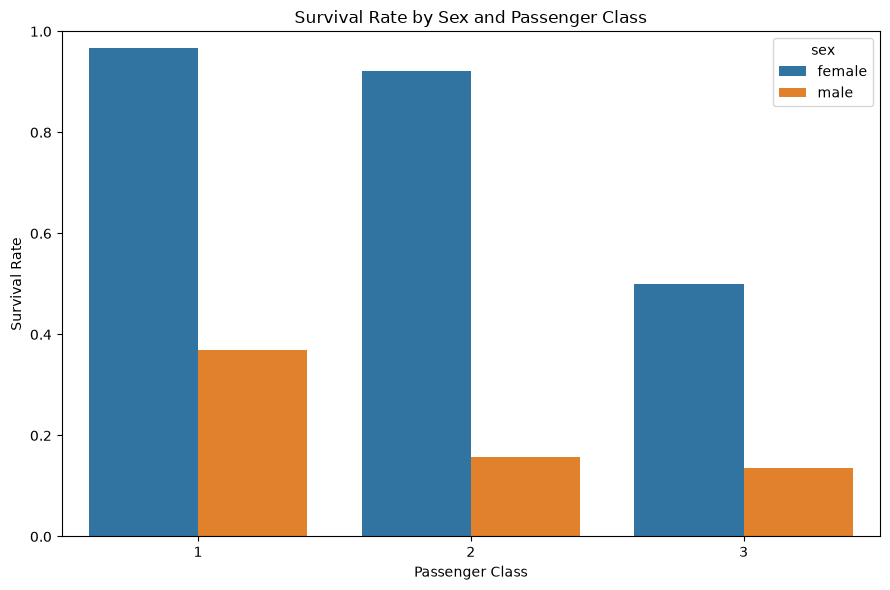

In [48]:
# Chart 1: Survival rate by Sex and Passenger Class

survival_sex_class = (
    df.groupby(["sex", "pclass"])["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=survival_sex_class,
    x="pclass",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Chart 1 Interpretation

Survival rates varied substantially by both sex and passenger class. Female passengers had higher survival rates than male passengers across the passenger classes, while first-class passengers generally had higher survival rates than passengers in lower classes. This shows that both sex and passenger class were important factors associated with survival.

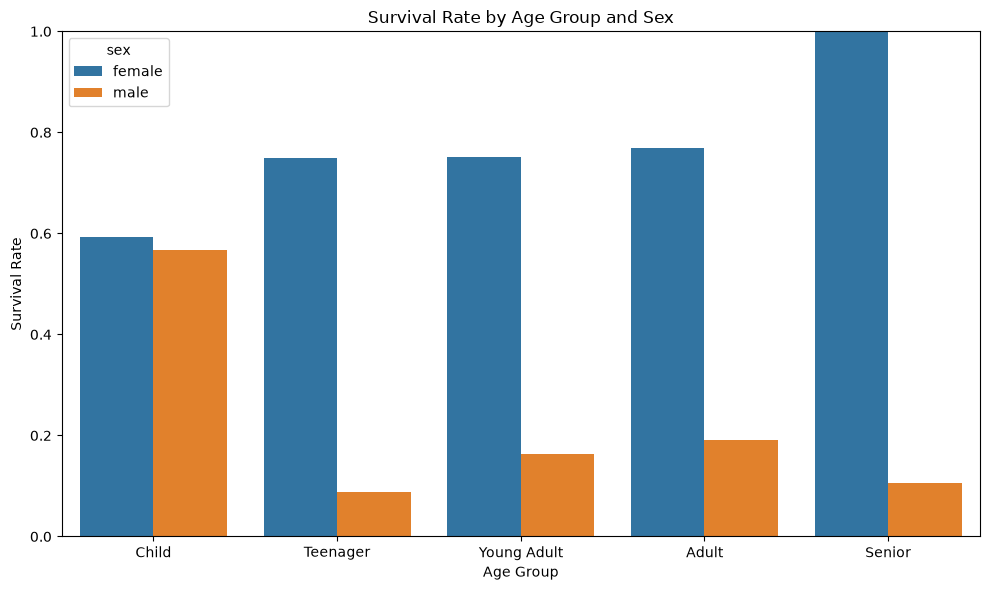

In [51]:
# Create age groups

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teenager", "Young Adult", "Adult", "Senior"]
)

# Calculate survival rate
age_sex_survival = (
    df.groupby(["age_group", "sex"], observed=False)["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_sex_survival,
    x="age_group",
    y="survived",
    hue="sex"
)

plt.title("Survival Rate by Age Group and Sex")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Chart 2 Interpretation

Survival rates differed across age groups and between males and females. Female passengers generally showed higher survival rates than males within the same age groups, although the pattern varies across groups. The chart helps show how age and sex together were associated with survival outcomes.

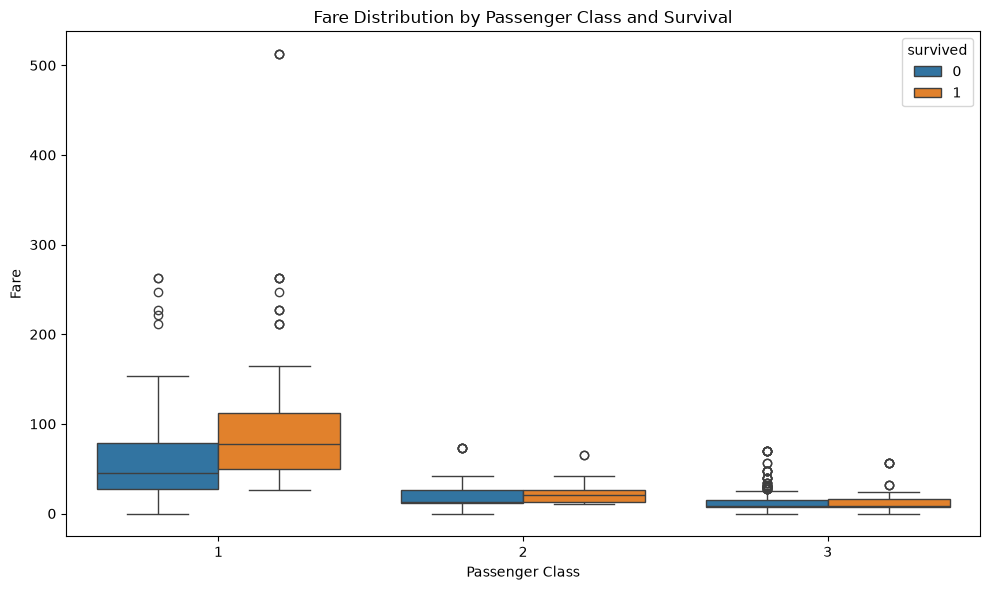

In [52]:
# Chart 3: Fare distribution by passenger class and survival

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)

plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()

### Chart 3 Interpretation

Fare levels differed strongly across passenger classes, with higher fares generally associated with higher passenger classes. Within each class, the fare distributions also varied between survivors and non-survivors. This suggests that economic position, represented by fare and class, was related to the survival outcome.

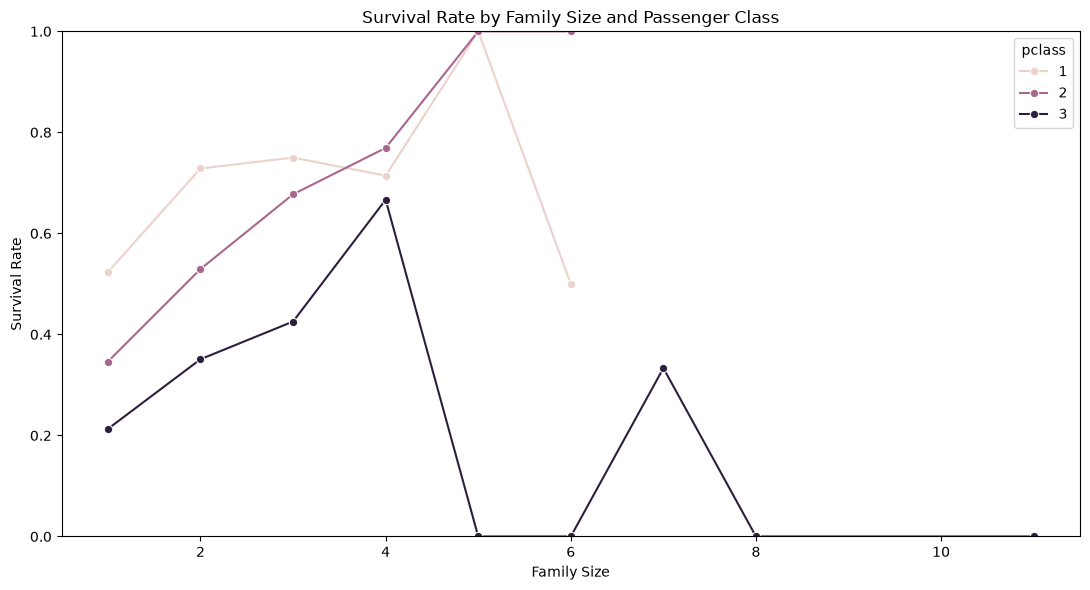

In [53]:
# Create family size
df["family_size"] = df["sibsp"] + df["parch"] + 1

# Survival rate by family size and passenger class
family_class_survival = (
    df.groupby(["family_size", "pclass"])["survived"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=family_class_survival,
    x="family_size",
    y="survived",
    hue="pclass",
    marker="o"
)

plt.title("Survival Rate by Family Size and Passenger Class")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Chart 4 Interpretation

Survival rates varied with family size and passenger class. The relationship between family size and survival was not uniform across all passenger classes, indicating that class influenced the survival pattern. Very small and very large family groups can show different survival outcomes.

In [54]:
# Create charts folder
os.makedirs("charts", exist_ok=True)

print("Charts folder is ready.")

Charts folder is ready.


In [56]:
# Standardize Age and Fare for EDA only

scaler_eda = StandardScaler()

df[["age_z", "fare_z"]] = scaler_eda.fit_transform(
    df[["age", "fare"]]
)

print("Age standardized successfully.")
print("Fare standardized successfully.")

Age standardized successfully.
Fare standardized successfully.


In [57]:
# Compare means and standard deviations before and after standardization

print("Before standardization:")
print("Age mean:", round(df["age"].mean(), 4))
print("Age std:", round(df["age"].std(), 4))
print("Fare mean:", round(df["fare"].mean(), 4))
print("Fare std:", round(df["fare"].std(), 4))

print("\nAfter standardization:")
print("Age z-score mean:", round(df["age_z"].mean(), 4))
print("Age z-score std:", round(df["age_z"].std(), 4))
print("Fare z-score mean:", round(df["fare_z"].mean(), 4))
print("Fare z-score std:", round(df["fare_z"].std(), 4))

Before standardization:
Age mean: 29.3152
Age std: 12.9849
Fare mean: 32.0967
Fare std: 49.6975

After standardization:
Age z-score mean: 0.0
Age z-score std: 1.0006
Fare z-score mean: 0.0
Fare z-score std: 1.0006


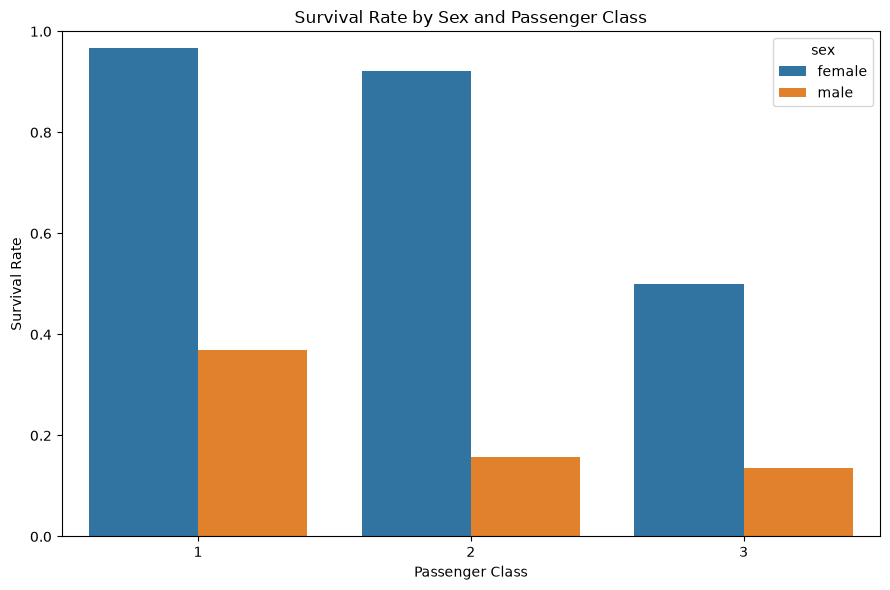

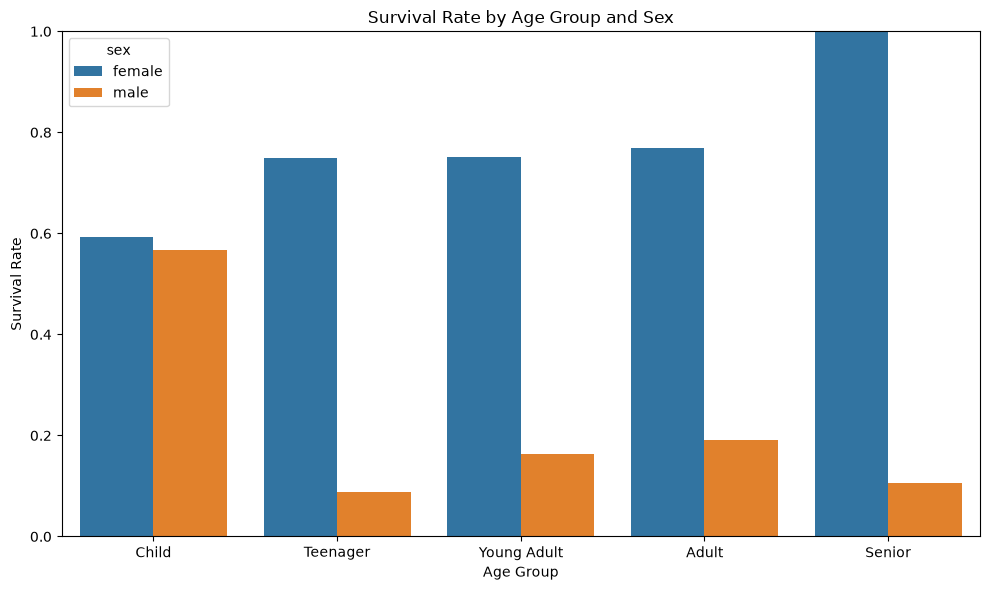

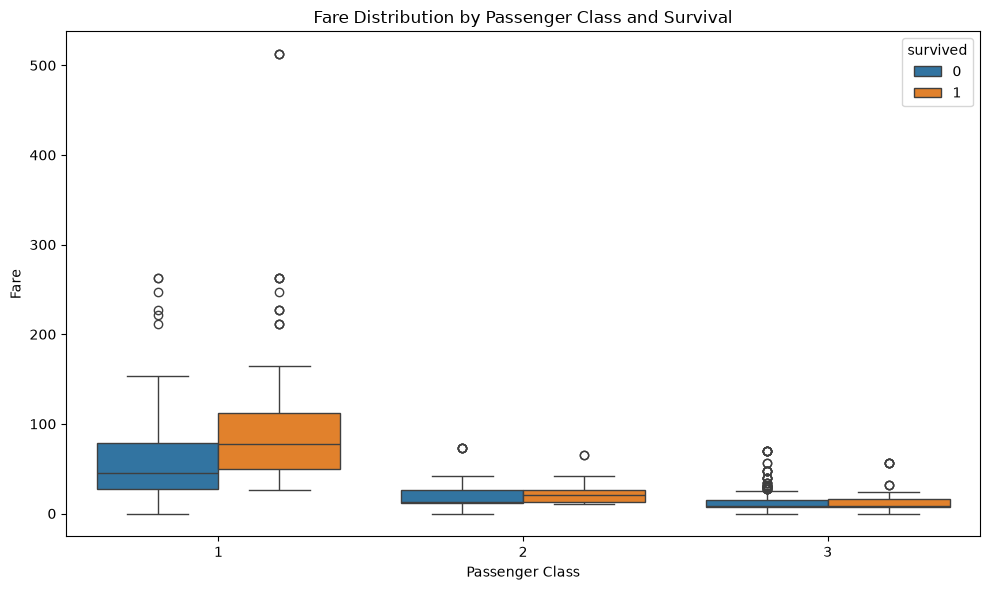

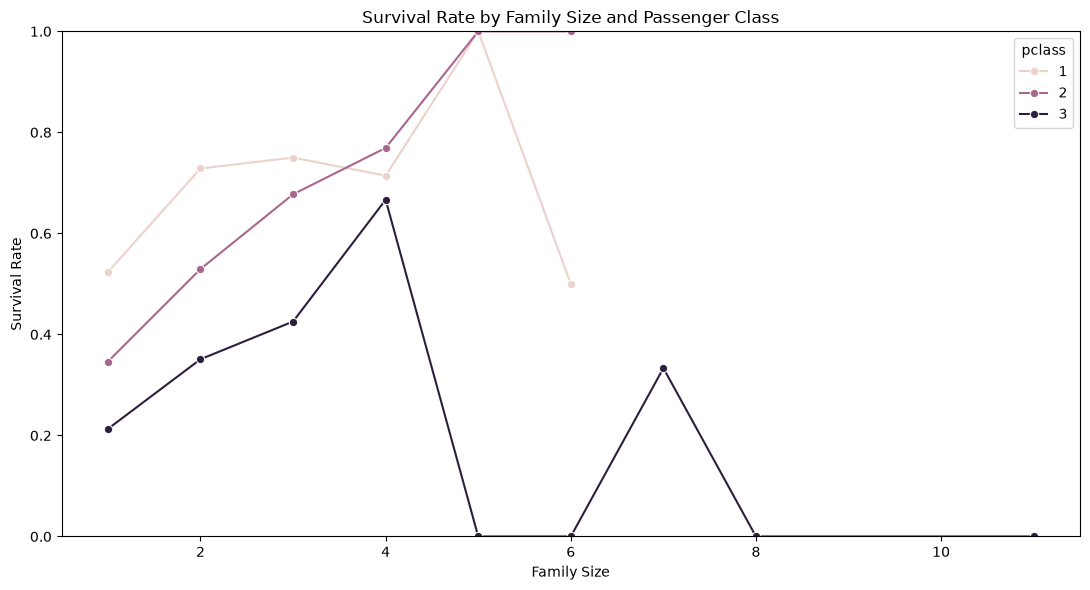

All 4 EDA charts saved successfully.


In [58]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)

# 1. Survival Rate by Sex and Passenger Class
plt.figure(figsize=(9, 6))
sns.barplot(
    data=df.groupby(["sex", "pclass"])["survived"].mean().reset_index(),
    x="pclass",
    y="survived",
    hue="sex"
)
plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("charts/survival_by_sex_class.png", dpi=150, bbox_inches="tight")
plt.show()


# 2. Survival Rate by Age Group and Sex
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df.groupby(["age_group", "sex"], observed=False)["survived"]
    .mean()
    .reset_index(),
    x="age_group",
    y="survived",
    hue="sex"
)
plt.title("Survival Rate by Age Group and Sex")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("charts/survival_by_age_group_sex.png", dpi=150, bbox_inches="tight")
plt.show()


# 3. Fare Distribution by Passenger Class and Survival
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)
plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig("charts/fare_by_class_survival.png", dpi=150, bbox_inches="tight")
plt.show()


# 4. Survival Rate by Family Size and Passenger Class
plt.figure(figsize=(11, 6))
sns.lineplot(
    data=df.groupby(["family_size", "pclass"])["survived"]
    .mean()
    .reset_index(),
    x="family_size",
    y="survived",
    hue="pclass",
    marker="o"
)
plt.title("Survival Rate by Family Size and Passenger Class")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("charts/survival_by_family_size_class.png", dpi=150, bbox_inches="tight")
plt.show()

print("All 4 EDA charts saved successfully.")

In [59]:
import os

print(os.listdir("charts"))

['confusion_matrices.png', 'decision_tree.png', 'fare_by_class_survival.png', 'fare_residual_plot.png', 'roc_curves.png', 'survival_by_age_group_sex.png', 'survival_by_family_size_class.png', 'survival_by_sex_class.png']


In [60]:
import os

print("Charts folder:")
for file in os.listdir("charts"):
    print(file)

print("\nTotal chart files:", len(os.listdir("charts")))

Charts folder:
confusion_matrices.png
decision_tree.png
fare_by_class_survival.png
fare_residual_plot.png
roc_curves.png
survival_by_age_group_sex.png
survival_by_family_size_class.png
survival_by_sex_class.png

Total chart files: 8


In [61]:
print("========== EDA FINAL RESULTS ==========")

print("\n1. MISSING VALUES")
print(missing_summary)

print("\n2. SURVIVAL RATE BY SEX")
print("Male:", round(male_rate * 100, 2), "%")
print("Female:", round(female_rate * 100, 2), "%")

print("\n3. SURVIVAL RATE BY CLASS")
print("1st Class:", round(first_class_rate * 100, 2), "%")
print("2nd Class:", round(second_class_rate * 100, 2), "%")
print("3rd Class:", round(third_class_rate * 100, 2), "%")

print("\n4. SURVIVAL RATE BY SEX AND CLASS")
for name, condition in groups:
    rate = df.loc[condition, "survived"].mean()
    print(name, ":", round(rate * 100, 2), "%")

# Recalculate the exact 6-column correlation
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        value = corr_matrix.iloc[i, j]

        corr_pairs.append(
            (col1, col2, value, abs(value))
        )

corr_pairs_sorted = sorted(
    corr_pairs,
    key=lambda x: x[3],
    reverse=True
)

print("\n5. STRONGEST CORRELATIONS")

for rank, pair in enumerate(corr_pairs_sorted[:2], start=1):
    print(
        rank,
        pair[0],
        "vs",
        pair[1],
        "=",
        round(pair[2], 4)
    )

print("\n6. AGE IQR OUTLIERS")
print(age_outliers)

print("\n7. FARE IQR OUTLIERS")
print(fare_outliers)

print("\n8. FARE STATISTICS")
print("Mean:", round(fare_mean, 4))
print("Median:", round(fare_median, 4))
print("Mode:", round(fare_mode, 4))
print("Skewness:", round(fare_skewness, 4))
print("Distribution:", fare_distribution)

print("\n9. STANDARDIZATION CHECK")
print("Age z-score mean:", round(df["age_z"].mean(), 4))
print("Age z-score std:", round(df["age_z"].std(), 4))
print("Fare z-score mean:", round(df["fare_z"].mean(), 4))
print("Fare z-score std:", round(df["fare_z"].std(), 4))

========== EDA FINAL RESULTS ==========

1. MISSING VALUES
             Missing Count  Missing Percentage
age                    177           19.865320
embarked                 2            0.224467
deck                   688           77.216611
embark_town              2            0.224467

2. SURVIVAL RATE BY SEX
Male: 18.89 %
Female: 74.04 %

3. SURVIVAL RATE BY CLASS
1st Class: 62.62 %
2nd Class: 47.28 %
3rd Class: 24.24 %

4. SURVIVAL RATE BY SEX AND CLASS
Male, 1st Class : 36.89 %
Male, 2nd Class : 15.74 %
Male, 3rd Class : 13.54 %
Female, 1st Class : 96.74 %
Female, 2nd Class : 92.11 %
Female, 3rd Class : 50.0 %

5. STRONGEST CORRELATIONS
1 pclass vs fare = -0.5482
2 sibsp vs parch = 0.4145

6. AGE IQR OUTLIERS
65

7. FARE IQR OUTLIERS
114

8. FARE STATISTICS
Mean: 32.0967
Median: 14.4542
Mode: 8.05
Skewness: 4.8014
Distribution: Right-skewed

9. STANDARDIZATION CHECK
Age z-score mean: 0.0
Age z-score std: 1.0006
Fare z-score mean: 0.0
Fare z-score std: 1.0006


In [62]:
print("=== STRONGEST 2 CORRELATIONS ===")
for rank, pair in enumerate(corr_pairs_sorted[:2], start=1):
    print(
        f"{rank}. {pair[0]} vs {pair[1]} = {pair[2]:.4f}"
    )

print("\n=== IQR OUTLIERS ===")
print("Age outliers:", age_outliers)
print("Fare outliers:", fare_outliers)

print("\n=== FARE STATISTICS ===")
print("Mean:", round(fare_mean, 4))
print("Median:", round(fare_median, 4))
print("Mode:", round(fare_mode, 4))
print("Skewness:", round(fare_skewness, 4))
print("Distribution:", fare_distribution)

=== STRONGEST 2 CORRELATIONS ===
1. pclass vs fare = -0.5482
2. sibsp vs parch = 0.4145

=== IQR OUTLIERS ===
Age outliers: 65
Fare outliers: 114

=== FARE STATISTICS ===
Mean: 32.0967
Median: 14.4542
Mode: 8.05
Skewness: 4.8014
Distribution: Right-skewed


In [63]:
# Handle embark_town missing values
embark_town_missing_percentage = (
    missing_count["embark_town"] / len(missing_count)
) * 100

print(
    "Embark_town missing percentage:",
    round(embark_town_missing_percentage, 4),
    "%"
)

df = df.drop(columns=["embark_town"])

print(
    "Decision: Dropped embark_town because it duplicates "
    "the embarkation information already represented by embarked."
)

print("\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Embark_town missing percentage: 13.3333 %
Decision: Dropped embark_town because it duplicates the embarkation information already represented by embarked.

Remaining missing values:
Series([], dtype: int64)


Embark_town: The original dataset had 2 missing values, which is 0.2245% of the 891 rows. The column was dropped because it duplicates the information represented by embarked. After missing-value handling, no missing values remain in the cleaned dataset.

So your final missing-value documentation should show:

Column	Missing	Percentage	Handling
age	177	19.8653%	Median imputation
embarked	2	0.2245%	Drop rows
deck	688	77.2166%	Drop column
embark_town	2	0.2245%	Drop column as redundant